In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Tổng hợp dữ liệu để ready cho việc phân tích pricing các sản phẩm

In [2]:
orders = pd.read_csv('../orders.csv')
orders_items = pd.read_csv('../order_items.csv')
products = pd.read_csv('../products.csv')


/var/folders/36/khn_y8zn7qqflczfpst8cbfc0000gn/T/ipykernel_99702/627756121.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  orders_items = pd.read_csv('../order_items.csv')


In [4]:
order_detail = orders.merge(orders_items, on='order_id', how='left').merge(products, on='product_id', how='left')


In [5]:
order_detail


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,product_id,quantity,...,discount_amount,promo_id,promo_id_2,product_name,category,segment,size,color,price,cogs
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,2400,7,...,0.0,NaN,NaN,VietMotion YY-09,GenZ,Trendy,S,red,1109.261061,1053.798008
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search,609,7,...,0.0,NaN,NaN,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,10426.571034,8987.704231
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,396,3,...,0.0,NaN,NaN,SaigonFlex UM-01,Streetwear,Balanced,S,green,11028.428695,10091.012256
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,635,5,...,0.0,NaN,NaN,SaigonFlex UC-00,Streetwear,Everyday,XL,purple,10745.220588,9205.430478
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,1935,1,...,0.0,NaN,NaN,UrbanVN RP-10,Outdoor,Activewear,XL,purple,1609.911509,1048.696357
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
714664,834372,2022-12-31,19490,33907,delivered,credit_card,mobile,email_campaign,690,8,...,0.0,NaN,NaN,SaigonFlex UC-55,Streetwear,Everyday,L,red,4598.817231,3100.062695
714665,834377,2022-12-31,73046,37091,delivered,credit_card,mobile,referral,1995,7,...,0.0,NaN,NaN,UrbanVN UM-02,Streetwear,Balanced,XL,purple,5159.312851,3025.421056
714666,834387,2022-12-31,107723,80516,delivered,credit_card,mobile,email_campaign,2331,8,...,0.0,NaN,NaN,VietMotion UE-05,Streetwear,Performance,XL,black,7365.661770,6671.816431
714667,834392,2022-12-31,139431,93510,delivered,paypal,desktop,direct,1115,5,...,0.0,NaN,NaN,MekongFit RS-03,Outdoor,Premium,XL,purple,4828.925117,4587.478861


In [6]:
order_detail['total_price'] = order_detail['unit_price'] * order_detail['quantity'] 
order_detail['total_cogs'] = order_detail['cogs'] * order_detail['quantity']
order_detail['profit'] = order_detail['total_price'] - order_detail['total_cogs']


In [7]:
order_detail


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,product_id,quantity,...,product_name,category,segment,size,color,price,cogs,total_price,total_cogs,profit
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,2400,7,...,VietMotion YY-09,GenZ,Trendy,S,red,1109.261061,1053.798008,7967.54,7376.586059,590.953941
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search,609,7,...,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,10426.571034,8987.704231,71163.75,62913.929616,8249.820384
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,396,3,...,SaigonFlex UM-01,Streetwear,Balanced,S,green,11028.428695,10091.012256,33660.99,30273.036767,3387.953233
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,635,5,...,SaigonFlex UC-00,Streetwear,Everyday,XL,purple,10745.220588,9205.430478,53196.25,46027.152390,7169.097610
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,1935,1,...,UrbanVN RP-10,Outdoor,Activewear,XL,purple,1609.911509,1048.696357,1597.84,1048.696357,549.143643
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
714664,834372,2022-12-31,19490,33907,delivered,credit_card,mobile,email_campaign,690,8,...,SaigonFlex UC-55,Streetwear,Everyday,L,red,4598.817231,3100.062695,35791.36,24800.501564,10990.858436
714665,834377,2022-12-31,73046,37091,delivered,credit_card,mobile,referral,1995,7,...,UrbanVN UM-02,Streetwear,Balanced,XL,purple,5159.312851,3025.421056,36755.53,21177.947390,15577.582610
714666,834387,2022-12-31,107723,80516,delivered,credit_card,mobile,email_campaign,2331,8,...,VietMotion UE-05,Streetwear,Performance,XL,black,7365.661770,6671.816431,59112.48,53374.531451,5737.948549
714667,834392,2022-12-31,139431,93510,delivered,paypal,desktop,direct,1115,5,...,MekongFit RS-03,Outdoor,Premium,XL,purple,4828.925117,4587.478861,23836.65,22937.394304,899.255696


In [8]:
order_detail['promo_counts'] = (
    order_detail['promo_id'].notna().astype(int) +
    order_detail['promo_id_2'].notna().astype(int)
)
order_detail


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,product_id,quantity,...,category,segment,size,color,price,cogs,total_price,total_cogs,profit,promo_counts
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,2400,7,...,GenZ,Trendy,S,red,1109.261061,1053.798008,7967.54,7376.586059,590.953941,0
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search,609,7,...,Streetwear,Everyday,M,yellow,10426.571034,8987.704231,71163.75,62913.929616,8249.820384,0
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,396,3,...,Streetwear,Balanced,S,green,11028.428695,10091.012256,33660.99,30273.036767,3387.953233,0
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,635,5,...,Streetwear,Everyday,XL,purple,10745.220588,9205.430478,53196.25,46027.152390,7169.097610,0
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,1935,1,...,Outdoor,Activewear,XL,purple,1609.911509,1048.696357,1597.84,1048.696357,549.143643,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
714664,834372,2022-12-31,19490,33907,delivered,credit_card,mobile,email_campaign,690,8,...,Streetwear,Everyday,L,red,4598.817231,3100.062695,35791.36,24800.501564,10990.858436,0
714665,834377,2022-12-31,73046,37091,delivered,credit_card,mobile,referral,1995,7,...,Streetwear,Balanced,XL,purple,5159.312851,3025.421056,36755.53,21177.947390,15577.582610,0
714666,834387,2022-12-31,107723,80516,delivered,credit_card,mobile,email_campaign,2331,8,...,Streetwear,Performance,XL,black,7365.661770,6671.816431,59112.48,53374.531451,5737.948549,0
714667,834392,2022-12-31,139431,93510,delivered,paypal,desktop,direct,1115,5,...,Outdoor,Premium,XL,purple,4828.925117,4587.478861,23836.65,22937.394304,899.255696,0


In [14]:
activewear_detail = order_detail[order_detail['segment'] == 'Activewear']
activewear_detail


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,product_id,quantity,...,category,segment,size,color,price,cogs,total_price,total_cogs,profit,promo_counts
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,1935,1,...,Outdoor,Activewear,XL,purple,1609.911509,1048.696357,1597.84,1048.696357,549.143643,0
5,7,2012-07-06,57820,2886,delivered,credit_card,tablet,organic_search,1934,6,...,Outdoor,Activewear,L,white,1609.911509,1337.836464,9800.94,8027.018786,1773.921214,0
6,8,2012-07-06,57818,2886,delivered,credit_card,mobile,email_campaign,1934,6,...,Outdoor,Activewear,L,white,1609.911509,1337.836464,9617.52,8027.018786,1590.501214,0
7,8,2012-07-06,57818,2886,delivered,credit_card,mobile,email_campaign,1935,4,...,Outdoor,Activewear,XL,purple,1609.911509,1048.696357,6570.04,4194.785429,2375.254571,0
8,9,2012-07-06,49102,5262,delivered,apple_pay,tablet,paid_search,1432,8,...,Outdoor,Activewear,S,orange,4093.740000,3889.053000,32397.12,31112.424000,1284.696000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
714639,834311,2022-12-28,134513,95062,delivered,credit_card,mobile,organic_search,736,6,...,Outdoor,Activewear,S,green,4615.655408,2839.089642,23071.50,17034.537851,6036.962149,1
714640,834312,2022-12-31,134609,95118,delivered,bank_transfer,desktop,paid_search,780,5,...,Outdoor,Activewear,S,red,3997.024413,2058.467573,15526.15,10292.337863,5233.812137,1
714650,834329,2022-12-31,149653,98391,delivered,cod,mobile,referral,736,3,...,Outdoor,Activewear,S,green,4615.655408,2839.089642,11103.48,8517.268925,2586.211075,1
714656,834347,2022-12-30,84850,50208,paid,credit_card,desktop,referral,1059,4,...,Outdoor,Activewear,XL,yellow,1979.360664,1058.364147,8114.16,4233.456588,3880.703412,0


In [10]:
activewear_detail_1 = activewear_detail.groupby(['order_date', 'category','size','color'])['price'].mean().reset_index()
activewear_detail_1



,order_date,category,size,color,price
0,2012-07-04,Outdoor,L,green,1611.780447
1,2012-07-04,Outdoor,L,orange,2941.168412
2,2012-07-04,Outdoor,L,red,2379.958580
3,2012-07-04,Outdoor,L,white,1064.008217
4,2012-07-04,Outdoor,M,black,2423.681005
...,...,...,...,...,...
58999,2022-12-31,Outdoor,S,white,2838.542746
59000,2022-12-31,Outdoor,XL,black,1125.994954
59001,2022-12-31,Outdoor,XL,blue,3901.311352
59002,2022-12-31,Outdoor,XL,purple,715.600872


In [11]:
activewear_detail_2 = activewear_detail.groupby(['order_date','category','size','color'])['quantity'].sum().reset_index()
activewear_detail_2


,order_date,category,size,color,quantity
0,2012-07-04,Outdoor,L,green,22
1,2012-07-04,Outdoor,L,orange,11
2,2012-07-04,Outdoor,L,red,4
3,2012-07-04,Outdoor,L,white,12
4,2012-07-04,Outdoor,M,black,10
...,...,...,...,...,...
58999,2022-12-31,Outdoor,S,white,15
59000,2022-12-31,Outdoor,XL,black,10
59001,2022-12-31,Outdoor,XL,blue,7
59002,2022-12-31,Outdoor,XL,purple,3


In [21]:
activewear_detail_3 = activewear_detail.groupby(['order_date','category'])[['promo_id']].nunique().reset_index()
activewear_detail_3


,order_date,category,promo_id
0,2012-07-04,Outdoor,0
1,2012-07-05,Outdoor,0
2,2012-07-06,Outdoor,0
3,2012-07-07,Outdoor,0
4,2012-07-08,Outdoor,0
...,...,...,...
4573,2022-12-28,Outdoor,1
4574,2022-12-29,Outdoor,1
4575,2022-12-30,Casual,1
4576,2022-12-30,Outdoor,1


In [22]:
activewear_detail_4 = activewear_detail.groupby(['order_date','category'])['promo_id_2'].nunique().reset_index()
activewear_detail_4


,order_date,category,promo_id_2
0,2012-07-04,Outdoor,0
1,2012-07-05,Outdoor,0
2,2012-07-06,Outdoor,0
3,2012-07-07,Outdoor,0
4,2012-07-08,Outdoor,0
...,...,...,...
4573,2022-12-28,Outdoor,0
4574,2022-12-29,Outdoor,0
4575,2022-12-30,Casual,0
4576,2022-12-30,Outdoor,0


In [26]:
activewear_detail = activewear_detail_1.merge(activewear_detail_2, on=['order_date','category','size','color'], how='left').merge(activewear_detail_3, on=['order_date','category'], how='left')


In [27]:
activewear_detail


,order_date,category,size,color,price,quantity,promo_id
0,2012-07-04,Outdoor,L,green,1611.780447,22,0
1,2012-07-04,Outdoor,L,orange,2941.168412,11,0
2,2012-07-04,Outdoor,L,red,2379.958580,4,0
3,2012-07-04,Outdoor,L,white,1064.008217,12,0
4,2012-07-04,Outdoor,M,black,2423.681005,10,0
...,...,...,...,...,...,...,...
58999,2022-12-31,Outdoor,S,white,2838.542746,15,1
59000,2022-12-31,Outdoor,XL,black,1125.994954,10,1
59001,2022-12-31,Outdoor,XL,blue,3901.311352,7,1
59002,2022-12-31,Outdoor,XL,purple,715.600872,3,1


In [28]:
activewear_detail['SKU'] = activewear_detail['category'] + '-' + activewear_detail['size'] + '-' + activewear_detail['color']
activewear_detail.drop(columns=[ 'category', 'size', 'color'], inplace=True)
activewear_detail


,order_date,price,quantity,promo_id,SKU
0,2012-07-04,1611.780447,22,0,Outdoor-L-green
1,2012-07-04,2941.168412,11,0,Outdoor-L-orange
2,2012-07-04,2379.958580,4,0,Outdoor-L-red
3,2012-07-04,1064.008217,12,0,Outdoor-L-white
4,2012-07-04,2423.681005,10,0,Outdoor-M-black
...,...,...,...,...,...
58999,2022-12-31,2838.542746,15,1,Outdoor-S-white
59000,2022-12-31,1125.994954,10,1,Outdoor-XL-black
59001,2022-12-31,3901.311352,7,1,Outdoor-XL-blue
59002,2022-12-31,715.600872,3,1,Outdoor-XL-purple


## Chỉ xét elasticity của sản phẩm trong segment Activewear, vì đây là segment có nhiều sản phẩm nhất và cũng là segment có nhiều đơn hàng nhất. Và chỉ xét những sản phẩm có số lượng đơn hàng trên 30 để có đủ dữ liệu cho việc phân tích.

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

elasticity_results = pd.DataFrame(columns=['SKU', 'elasticity', 'r2'])
left_sku = []
sku_models = []
for product in activewear_detail['SKU'].unique():
    product_detail = activewear_detail[activewear_detail['SKU'] == product]
    print("=="*50)
    # Chỉ phân tích những sản phẩm có số lượng đơn hàng trên 30 để có đủ dữ liệu cho việc phân tích
    if product_detail.shape[0] < 30:
        print(f"Product {product} has insufficient data for elasticity estimation. Skipping.")
        left_sku.append(product)
        continue
    # Loại bỏ outliers để tránh ảnh hưởng đến kết quả phân tích
    q_low  = product_detail['quantity'].quantile(0.05)
    q_high = product_detail['quantity'].quantile(0.95)
    product_detail = product_detail[(product_detail['quantity'] > q_low) &
                                   (product_detail['quantity'] < q_high)]
    # Log-transform để linearize mối quan hệ giữa quantity và profit
    ln_quantity  = np.array(np.log(product_detail['quantity'].clip(lower=1))).reshape(-1,1)
    ln_price = np.array(np.log(product_detail['price'].clip(lower=1))).reshape(-1,1)

    # Fit log - log linear regression model để ước lượng elasticity
    elas_model = LinearRegression().fit(ln_price, ln_quantity)
    elasticity = elas_model.coef_[0]
    r2         = r2_score(np.exp(ln_quantity), np.exp(elas_model.predict(ln_price.reshape(-1, 1))))
    
    elasticity_results = pd.concat([
    elasticity_results,
    pd.DataFrame([{
        'SKU': product,
        'elasticity': elasticity,
        'r2': r2
    }])
], ignore_index=True)

    print(f"Product ID: {product}")
    print(f"Estimated Elasticity: {elasticity[0]:.2f}")
    sku_models.append((product, elas_model))    
    


Product ID: Outdoor-L-green
Estimated Elasticity: 0.12
Product ID: Outdoor-L-orange
Estimated Elasticity: -0.25
Product ID: Outdoor-L-red
Estimated Elasticity: -0.21
Product ID: Outdoor-L-white
Estimated Elasticity: -0.16
Product ID: Outdoor-M-black
Estimated Elasticity: -0.25
Product ID: Outdoor-M-blue
Estimated Elasticity: -0.09
Product ID: Outdoor-M-purple
Estimated Elasticity: 0.30
Product ID: Outdoor-M-yellow
Estimated Elasticity: -0.10
Product ID: Outdoor-S-orange
Estimated Elasticity: -0.36
Product ID: Outdoor-S-red
Estimated Elasticity: 0.03
Product ID: Outdoor-S-white
Estimated Elasticity: 0.12


/var/folders/36/khn_y8zn7qqflczfpst8cbfc0000gn/T/ipykernel_99702/2437322524.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  elasticity_results = pd.concat([


Product ID: Outdoor-XL-black
Estimated Elasticity: -0.35
Product ID: Outdoor-XL-blue
Estimated Elasticity: 0.08
Product ID: Outdoor-XL-purple
Estimated Elasticity: -0.16
Product ID: Outdoor-M-silver
Estimated Elasticity: -0.22
Product ID: Outdoor-S-green
Estimated Elasticity: 0.08
Product ID: Outdoor-XL-silver
Estimated Elasticity: -0.09
Product ID: Outdoor-XL-yellow
Estimated Elasticity: 0.09
Product ID: Outdoor-S-pink
Estimated Elasticity: -0.31
Product ID: Outdoor-L-pink
Estimated Elasticity: -0.27
Product ID: Casual-XL-yellow
Estimated Elasticity: 0.46
Product ID: Casual-S-red
Estimated Elasticity: 0.06
Product ID: Casual-S-orange
Estimated Elasticity: 0.04
Product ID: Casual-XL-black
Estimated Elasticity: -0.12
Product ID: Casual-L-white
Estimated Elasticity: 0.12
Product ID: Casual-M-blue
Estimated Elasticity: -0.09
Product ID: Casual-L-orange
Estimated Elasticity: -0.03
Product ID: Casual-M-black
Estimated Elasticity: 0.00
Product ID: Casual-S-white
Estimated Elasticity: 0.92
Pr

In [35]:
left_sku


['Casual-S-green',
 'Casual-XL-purple',
 'Casual-S-pink',
 'Casual-XL-silver',
 'Casual-M-yellow',
 'Casual-L-red']

In [36]:
elasticity_results.sort_values(by='elasticity', ascending=False)


,SKU,elasticity,r2
28,Casual-S-white,[0.9183397610365504],-0.038757
20,Casual-XL-yellow,[0.4642078027982268],-0.042864
6,Outdoor-M-purple,[0.3000038536797367],-0.108634
10,Outdoor-S-white,[0.12207222026031286],-0.074482
24,Casual-L-white,[0.11765413619983595],-0.051641
0,Outdoor-L-green,[0.11650386539810066],-0.099556
17,Outdoor-XL-yellow,[0.0893045542318702],-0.101348
12,Outdoor-XL-blue,[0.07978257157225457],-0.077381
15,Outdoor-S-green,[0.07505848610002577],-0.090303
21,Casual-S-red,[0.05964147935102939],-0.041277


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31],
 [Text(0, 0, 'Outdoor-L-green'),
  Text(1, 0, 'Outdoor-L-orange'),
  Text(2, 0, 'Outdoor-L-red'),
  Text(3, 0, 'Outdoor-L-white'),
  Text(4, 0, 'Outdoor-M-black'),
  Text(5, 0, 'Outdoor-M-blue'),
  Text(6, 0, 'Outdoor-M-purple'),
  Text(7, 0, 'Outdoor-M-yellow'),
  Text(8, 0, 'Outdoor-S-orange'),
  Text(9, 0, 'Outdoor-S-red'),
  Text(10, 0, 'Outdoor-S-white'),
  Text(11, 0, 'Outdoor-XL-black'),
  Text(12, 0, 'Outdoor-XL-blue'),
  Text(13, 0, 'Outdoor-XL-purple'),
  Text(14, 0, 'Outdoor-M-silver'),
  Text(15, 0, 'Outdoor-S-green'),
  Text(16, 0, 'Outdoor-XL-silver'),
  Text(17, 0, 'Outdoor-XL-yellow'),
  Text(18, 0, 'Outdoor-S-pink'),
  Text(19, 0, 'Outdoor-L-pink'),
  Text(20, 0, 'Casual-XL-yellow'),
  Text(21, 0, 'Casual-S-red'),
  Text(22, 0, 'Casual-S-orange'),
  Text(23, 0, 'Casual-XL-black'),
  Text(2

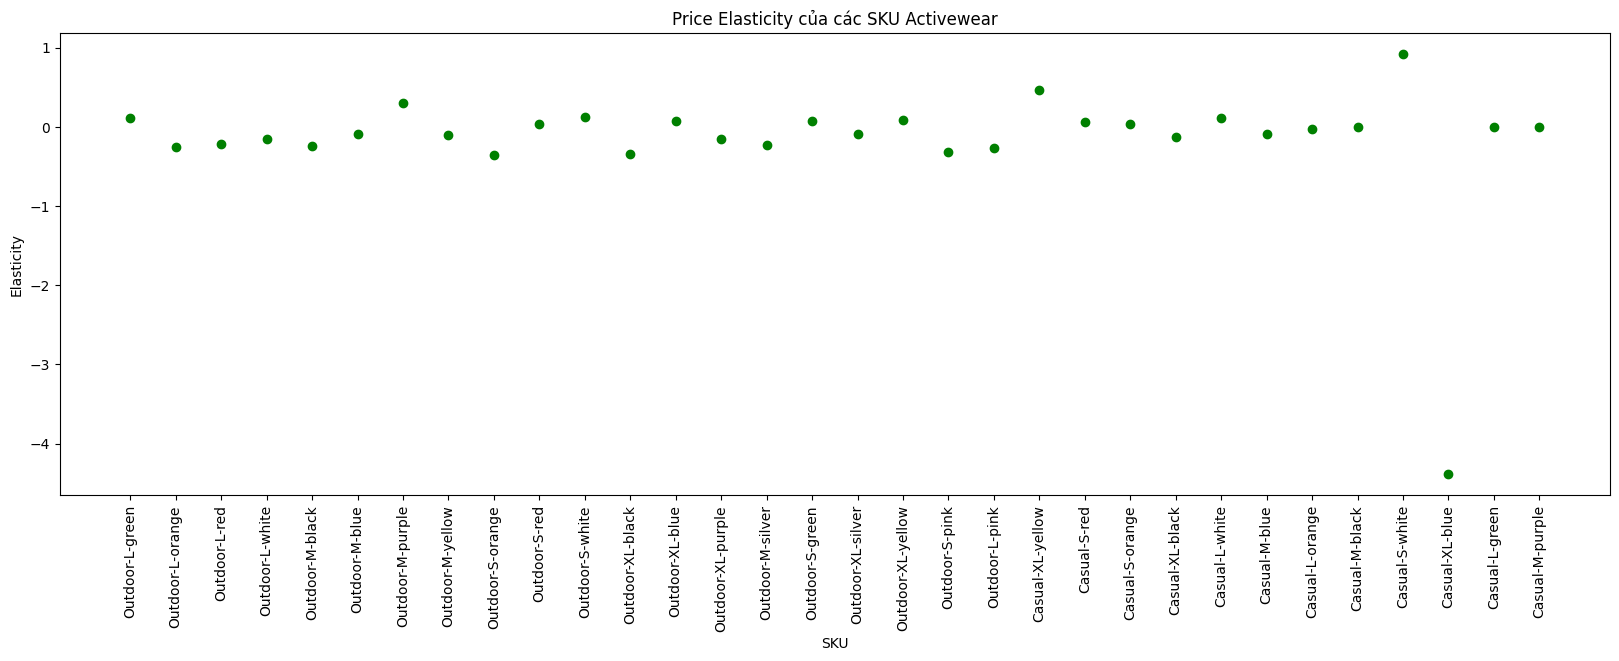

In [144]:
# Scatter plot of elasticity with product_id legend
plt.figure(figsize=(20, 6))
plt.scatter(elasticity_results['SKU'], elasticity_results['elasticity'], color='green')
plt.title('Price Elasticity của các SKU Activewear')
plt.xlabel('SKU')
plt.ylabel('Elasticity')
plt.xticks(rotation=90)


<Axes: xlabel='price', ylabel='quantity'>

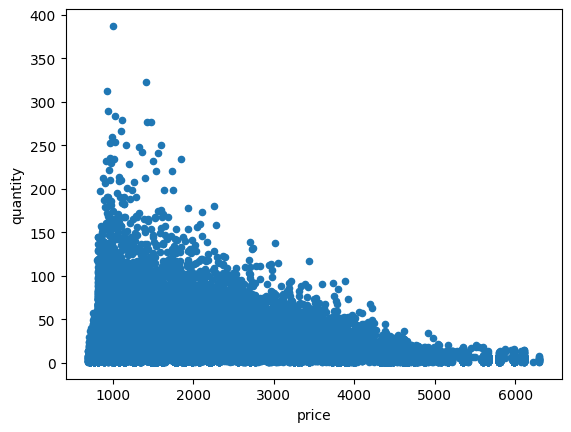

In [142]:
activewear_detail[['price','quantity']].plot.scatter(x='price', y='quantity')


Từ biểu đồ này có thể thấy rằng có một số sản phẩm có giá rất cao nhưng vẫn bán được nhiều, điều này cho thấy rằng những sản phẩm này có thể có độ co giãn giá thấp (inelastic), nghĩa là người tiêu dùng vẫn sẽ mua chúng ngay cả khi giá tăng. Ngược lại, có những sản phẩm có giá thấp nhưng bán được ít, điều này cho thấy rằng những sản phẩm này có thể có độ co giãn giá cao (elastic), nghĩa là người tiêu dùng sẽ giảm mua chúng nếu giá tăng.